In [4]:
import pandas as pd
df = pd.read_csv("../data/raw/creditcard.csv")

In [16]:
print(df.head())
print(df.shape)
print(df.info())
print(df.describe())

   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

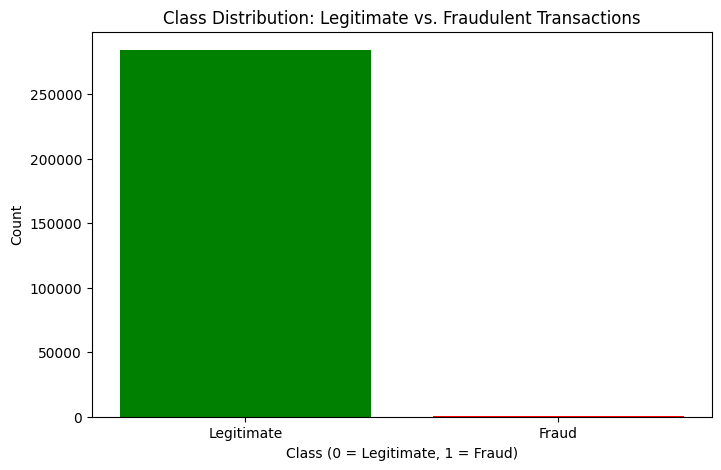

In [6]:
import matplotlib.pyplot as plt

# Count the occurrences of each class
class_counts = df['Class'].value_counts()

# Create the barplot
plt.figure(figsize=(8, 5))
plt.bar(class_counts.index, class_counts.values, color=['green', 'red'])
plt.title('Class Distribution: Legitimate vs. Fraudulent Transactions')
plt.xlabel('Class (0 = Legitimate, 1 = Fraud)')
plt.ylabel('Count')
plt.xticks(class_counts.index, ['Legitimate', 'Fraud'])
plt.show()

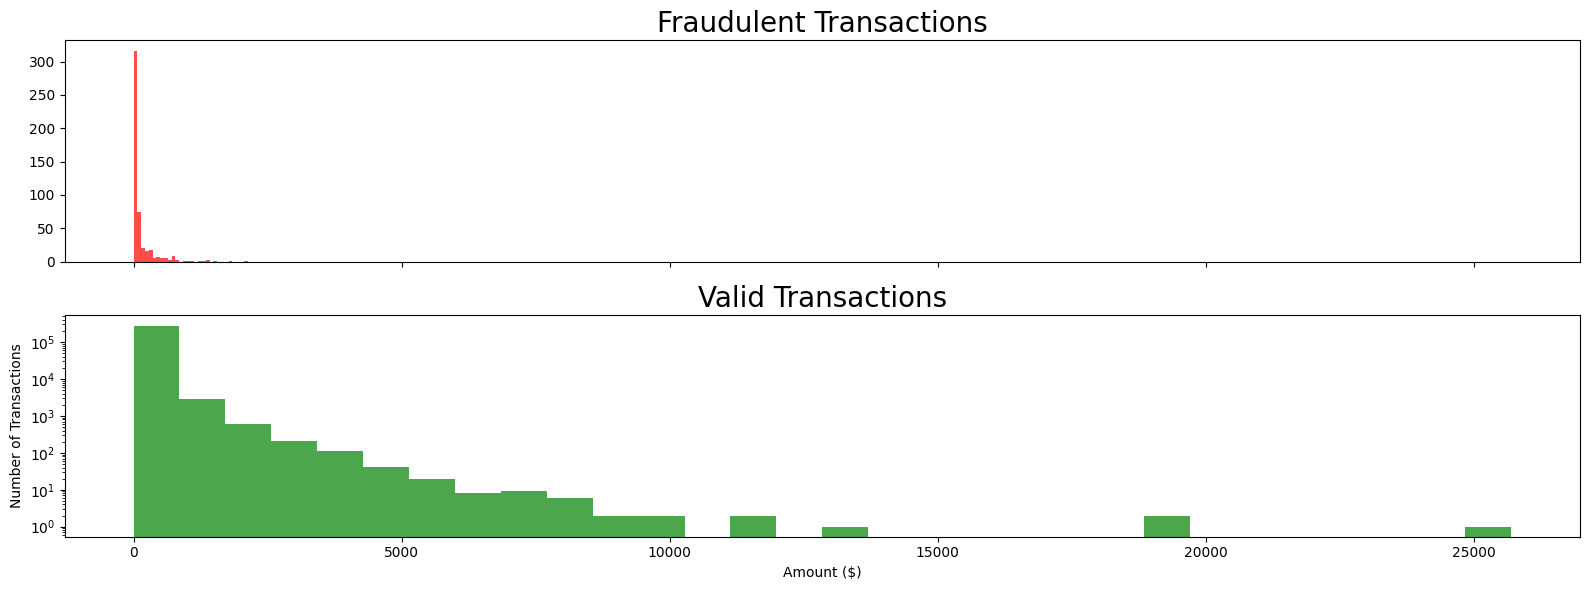

In [10]:
# Separate valid and fraudulent transactions
fraudulent = df[df['Class'] == 1]['Amount']
valid = df[df['Class'] == 0]['Amount']

# Create subplots for comparison
f, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(16, 6))

# Histogram for fraudulent transactions
ax1.hist(fraudulent, bins=30, color='red', alpha=0.7)
ax1.set_title('Fraudulent Transactions', fontsize=20)

# Histogram for valid transactions
ax2.hist(valid, bins=30, color='green', alpha=0.7)
ax2.set_title('Valid Transactions', fontsize=20)

plt.xlabel('Amount ($)')
plt.ylabel('Number of Transactions')
plt.yscale('log')  # Use log scale for better visualization of rare events
plt.tight_layout()
plt.show()

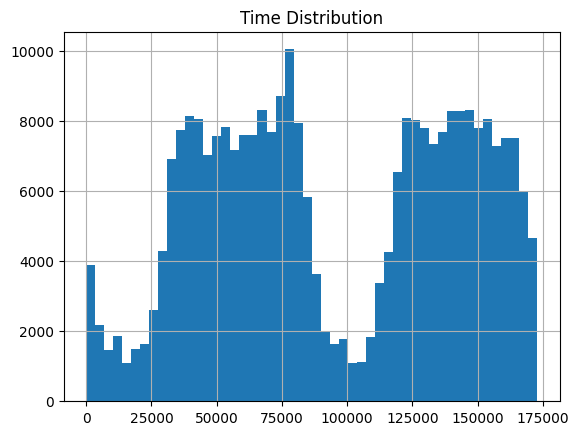

In [11]:
df["Time"].hist(bins=50)
plt.title("Time Distribution")
plt.show()

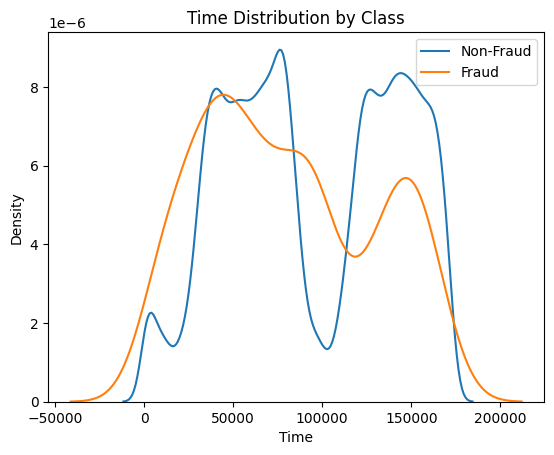

In [17]:
import seaborn as sns

sns.kdeplot(df[df["Class"] == 0]["Time"], label="Non-Fraud")
sns.kdeplot(df[df["Class"] == 1]["Time"], label="Fraud")

plt.legend()
plt.title("Time Distribution by Class")
plt.show()

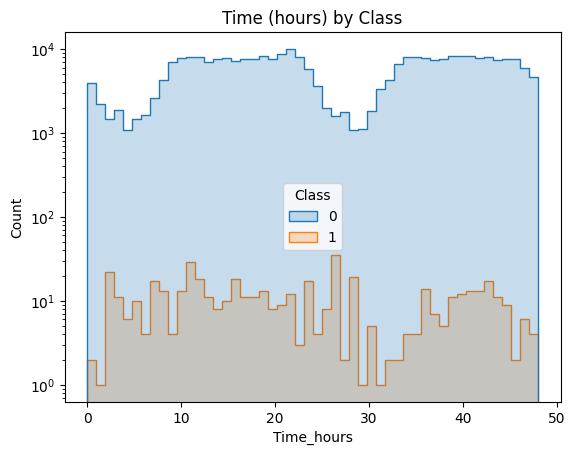

In [19]:
df["Time_hours"] = df["Time"] / 3600

sns.histplot(data=df, x="Time_hours", hue="Class", bins=50, element="step")
plt.title("Time (hours) by Class")
plt.yscale('log') 
plt.show()

In [32]:
corr = df.corr()

target_corr = corr["Class"].sort_values(ascending=False)

print(target_corr)

Class         1.000000
V11           0.149067
V4            0.129326
V2            0.084624
V19           0.033631
V8            0.033068
V21           0.026357
V27           0.021892
V20           0.021486
V28           0.009682
Amount        0.005777
V22           0.004887
V26           0.004265
V25           0.003202
V15          -0.003300
V13          -0.003897
V23          -0.006333
V24          -0.007210
Time         -0.012359
Time_hours   -0.012359
V6           -0.043915
V5           -0.087812
V9           -0.094021
V1           -0.094486
V18          -0.105340
V7           -0.172347
V3           -0.182322
V16          -0.187186
V10          -0.206971
V12          -0.250711
V14          -0.293375
V17          -0.313498
Name: Class, dtype: float64


In [22]:
df.duplicated().sum()

np.int64(1081)

In [25]:
duplicates = df[df.duplicated()]
duplicates.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V22,V23,V24,V25,V26,V27,V28,Amount,Class,Time_hours
33,26.0,-0.529912,0.873892,1.347247,0.145457,0.414209,0.100223,0.711206,0.176066,-0.286717,...,0.208105,-0.185548,0.001031,0.098816,-0.552904,-0.073288,0.023307,6.14,0,0.007222
35,26.0,-0.535388,0.865268,1.351076,0.147575,0.433680,0.086983,0.693039,0.179742,-0.285642,...,0.206537,-0.187108,0.000753,0.098117,-0.553471,-0.078306,0.025427,1.77,0,0.007222
113,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,...,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0,0.020556
114,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,...,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0,0.020556
115,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,...,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0,0.020556


In [27]:
df[df.duplicated(keep=False)].sort_values(by=list(df.columns)).head(10)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V22,V23,V24,V25,V26,V27,V28,Amount,Class,Time_hours
34,26.0,-0.535388,0.865268,1.351076,0.147575,0.433680,0.086983,0.693039,0.179742,-0.285642,...,0.206537,-0.187108,0.000753,0.098117,-0.553471,-0.078306,0.025427,1.77,0,0.007222
35,26.0,-0.535388,0.865268,1.351076,0.147575,0.433680,0.086983,0.693039,0.179742,-0.285642,...,0.206537,-0.187108,0.000753,0.098117,-0.553471,-0.078306,0.025427,1.77,0,0.007222
32,26.0,-0.529912,0.873892,1.347247,0.145457,0.414209,0.100223,0.711206,0.176066,-0.286717,...,0.208105,-0.185548,0.001031,0.098816,-0.552904,-0.073288,0.023307,6.14,0,0.007222
33,26.0,-0.529912,0.873892,1.347247,0.145457,0.414209,0.100223,0.711206,0.176066,-0.286717,...,0.208105,-0.185548,0.001031,0.098816,-0.552904,-0.073288,0.023307,6.14,0,0.007222
112,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,...,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0,0.020556
113,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,...,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0,0.020556
114,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,...,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0,0.020556
115,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,...,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0,0.020556
220,145.0,-2.420413,1.947885,0.553646,0.983069,-0.281518,2.408958,-1.401613,-0.188299,0.675878,...,-1.238620,0.006927,-1.724222,0.239603,-0.313703,-0.188281,0.119831,6.00,0,0.040278
221,145.0,-2.420413,1.947885,0.553646,0.983069,-0.281518,2.408958,-1.401613,-0.188299,0.675878,...,-1.238620,0.006927,-1.724222,0.239603,-0.313703,-0.188281,0.119831,6.00,0,0.040278


In [28]:
duplicates["Class"].value_counts()

Class
0    1062
1      19
Name: count, dtype: int64

In [29]:
df = df.drop_duplicates()